# **1. 오토인코더**
오토인코더(Autoencoder)는 입력 데이터를 효율적으로 압축하고 다시 복원하는 것을 목표로 하는 인공신경망 기반의 비지도 학습 모델입니다. 인코더(encoder)라는 신경망 구조를 통해 입력 데이터를 저차원(latent space)(실수)의 잠재 표현으로 변환하고, 디코더(decoder)를 통해 이를 다시 원래의 입력 데이터로 복원합니다. 학습은 원본 입력과 복원된 출력 간의 재구성 오류(reconstruction error)를 최소화하는 방식으로 이루어지며, 이를 통해 데이터의 핵심 특징을 추출하거나 노이즈 제거, 차원 축소 등에 활용됩니다. 오토인코더는 생성 모델의 기초가 되는 구조로서, 이후 변분 오토인코더(VAE)나 GAN과 같은 발전된 모델에도 큰 영향을 주었습니다.
![오토인코더](./images/오토인코더.png)

- Autoencoder는 입력을 정답으로 사용하는 신경망
- 예) 숫자 이미지 7을 입력하면 정답도 7 이미지
```
    입력 이미지 x > Encoder > Latent Vector z > Decoder > 복원 이미지 x_hat
```
> 원본 x와 복원된 결과 x_hat의 차이가 작아지도록 학습

### 비지도 학습

- 일반적인 이미지 분류
    - 강아지 이미지 > CNN > "강아지"
- Autoencoder
    - 강아지 이미지 > Encoder > Latent > Decoder > 강아지 이미지
    - 별도의 클래스 라벨이 필요하지 않기 때문에 전통적으로 비지도 학습 또는 자기지도적 표현 학습의 한 형태로 말함(입력이 곧 정답이므로)

### 1. Encoder
- Encoder는 입력을 더 작은 표현으로 바꿈
- 예) MNIST 이미지는 28 * 28 (784 픽셀) > Encoder > 784차원에서 128차원, 32차원으로 줄임
- 신경망이 복원에 필요한 특징을 스스로 학습

### 2. Decoder
- Decoder는 Encoder와 반대 방향으로 동작
- 예) latent z (32개 값) > Decoder > 784차원(28 * 28)
- Encoder가 남긴 제한된 정보만 보고 원본과 최대한 비슷한 데이터를 만드는 것

### 3. Reconstruction Loss
- Autoencoder는 원본과 복원본이 얼마나 다른지를 Loss로 계산
- 예) 원본 픽셀: 0.8, 복원된 픽셀: 0.6 > 오차 = (0.8 - 0.6)**2 = 0.04
- 모든 픽셀의 오차를 줄이도록 Encoder와 Decoder의 파라미터를 동시에 업데이트

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

torch.manual_seed(2026)

In [3]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.xpu.is_available():
    DEVICE = torch.device('xpu')
else:
    DEVICE = torch.device('cpu')

print(DEVICE)

cpu


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=4)

images, labels = next(iter(train_loader))
print("images:", images.shape)   # [B, 1, 28, 28]
print("labels:", labels.shape)

100%|██████████| 9.91M/9.91M [00:02<00:00, 3.75MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 100kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 467kB/s]


images: torch.Size([128, 1, 28, 28])
labels: torch.Size([128])


In [ ]:
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            # 1 * 28 * 28 (흑백이라 1)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # 28 -> 14 stride때문에 이미지 크기 줄음. 다만 특징 개수는 별개
            # 16 * 14 * 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # 14 -> 7
            # 32 * 7 * 7
            nn.ReLU(),
        )

        self.decoder = nn.Sequential(
            # conv2d는 사이즈를 키우고 stride로만 크기를 줄이기 때문(공간을 키우진 못함)에 아예 다른 convtranspose2d를 써야함
            nn.ConvTranspose2d( # 크기를 키움
                32, 16, kernel_size=3, stride=2, 
                padding=1, output_padding=1
            ),                                                     # 7 -> 14
            nn.ReLU(),
            nn.ConvTranspose2d(
                16, 1, kernel_size=3, stride=2,
                padding=1, output_padding=1
            ),                                                     # 14 -> 28
            nn.Sigmoid() # 입력받은 값과 범위를 맞춰주기 위해
        )
        # Totensor()로 읽은 이미지 픽셀 값은 0~1 범위
        # Decoder의 마지막 출력도 0~1 범위가 되도록 설정

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return z, x_hat


model = ConvAutoencoder().to(DEVICE)
model

ConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [8]:
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3)

def train_autoencoder(model, loader, criterion, optimizer, device, epochs=5):
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x, _ in loader:
            x = x.to(device)

            _, x_hat = model(x)
            loss = criterion(x_hat, x) # 지도학습의 label 역할

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)

        epoch_loss = running_loss / len(loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch+1:02d}/{epochs} | Loss: {epoch_loss:.6f}")

    return history

history = train_autoencoder(
    model, train_loader, criterion, optimizer, DEVICE, epochs=5
)

Epoch 01/5 | Loss: 0.031372
Epoch 02/5 | Loss: 0.001786
Epoch 03/5 | Loss: 0.001210
Epoch 04/5 | Loss: 0.000970
Epoch 05/5 | Loss: 0.000810


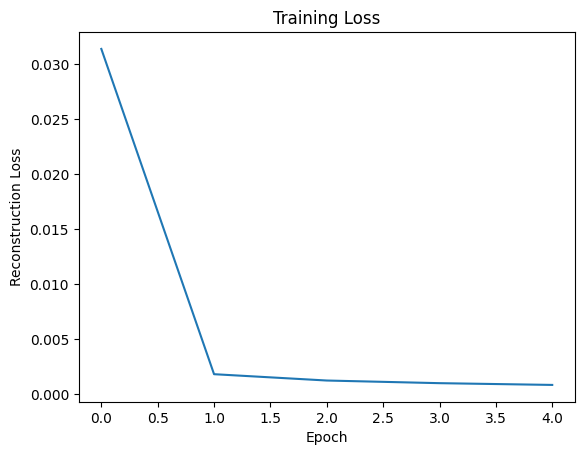

In [9]:
plt.plot(history)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Training Loss")
plt.show()

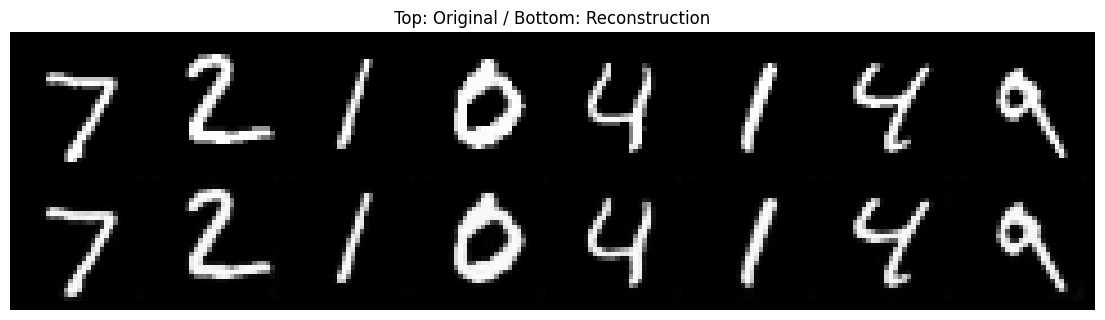

In [ ]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader)) # 정답은 필요없어 안가져옴
    x = x[:n].to(device)

    _, x_hat = model(x)

    comparison = torch.cat([x.cpu(), x_hat.cpu()], dim=0)
    grid = make_grid(comparison, nrow=n, padding=2)

    plt.figure(figsize=(14, 4))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")
    plt.axis("off")
    plt.title("Top: Original / Bottom: Reconstruction")
    plt.show()

show_reconstructions(model, test_loader, DEVICE)

# 위의 행이 원본
# 아래 행이 autoencoder로 복원한 행

autoencoder
생성형
원본과 다른 이미지를 생성하기 위해 예전에 사용했음